# IT325 Machine Learning — Lab Activity 2
## Exploratory Data Analysis: Asthma Disease Dataset

**Student:** John Michael Angelo Binonggo  
**Course:** IT325 Machine Learning  
**Activity:** Lab Activity 2 — EDA Implementation  
**Dataset:** `asthma_disease_data.csv`  
**Date:** April 21, 2026

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Dataset Overview
### 2.1 Load the Dataset

In [2]:
df = pd.read_csv('asthma_disease_data.csv')

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('First 5 rows:')
df.head()

Dataset loaded: 2392 rows × 29 columns

First 5 rows:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid


### 2.2 Shape, Column Names, and Data Types

In [3]:
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns\n')
print('Column names and data types:')
print(df.dtypes.to_string())

Shape: 2392 rows, 29 columns

Column names and data types:
PatientID                   int64
Age                         int64
Gender                      int64
Ethnicity                   int64
EducationLevel              int64
BMI                       float64
Smoking                     int64
PhysicalActivity          float64
DietQuality               float64
SleepQuality              float64
PollutionExposure         float64
PollenExposure            float64
DustExposure              float64
PetAllergy                  int64
FamilyHistoryAsthma         int64
HistoryOfAllergies          int64
Eczema                      int64
HayFever                    int64
GastroesophagealReflux      int64
LungFunctionFEV1          float64
LungFunctionFVC           float64
Wheezing                    int64
ShortnessOfBreath           int64
ChestTightness              int64
Coughing                    int64
NighttimeSymptoms           int64
ExerciseInduced             int64
Diagnosis              

In [4]:
print('Basic Descriptive Statistics:')
df.describe().T

Basic Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
PatientID,2392.0,6229.500000,690.655244,5034.000000,5631.750000,6229.500000,6827.250000,7425.000000
Age,2392.0,42.137960,21.606655,5.000000,23.000000,42.000000,61.000000,79.000000
Gender,2392.0,0.493311,0.500060,0.000000,0.000000,0.000000,1.000000,1.000000
Ethnicity,2392.0,0.669732,0.986120,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2392.0,1.307274,0.898242,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2392.0,27.244877,7.201628,15.031803,20.968313,27.052202,33.555903,39.985611
Smoking,2392.0,0.141722,0.348838,0.000000,0.000000,0.000000,0.000000,1.000000
PhysicalActivity,2392.0,5.051786,2.903574,0.001740,2.578333,5.016881,7.540234,9.995809
DietQuality,2392.0,5.022867,2.909980,0.003031,2.432043,5.115383,7.544216,9.999904
SleepQuality,2392.0,7.019012,1.732475,4.001437,5.498500,6.975839,8.526950,9.996235


---
## 3. Data Quality Checks
### 3.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})

print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else 'No missing values found. Dataset is complete.')

Missing Values Summary:
No missing values found. Dataset is complete.


### 3.2 Duplicate Rows

In [6]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates == 0:
    print('No duplicate rows detected. Dataset integrity is intact.')
else:
    print(f'Found {duplicates} duplicate rows. Consider dropping them before modeling.')

Number of duplicate rows: 0
No duplicate rows detected. Dataset integrity is intact.


### 3.3 Irrelevant Columns

Two columns — `PatientID` and `DoctorInCharge` — are identifiers that carry no predictive value. They will be excluded from analysis.

In [7]:
# Drop non-informative columns for analysis
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

print(f'Working dataset shape after dropping identifiers: {df_clean.shape}')
print(f'Remaining columns: {df_clean.columns.tolist()}')

Working dataset shape after dropping identifiers: (2392, 27)
Remaining columns: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis']


---
## 4. Class Distribution (Target Variable: `Diagnosis`)

The `Diagnosis` column is the target variable:  
- **0** = No Asthma  
- **1** = Asthma Diagnosed

In [8]:
class_counts = df_clean['Diagnosis'].value_counts()
class_labels = {0: 'No Asthma (0)', 1: 'Asthma (1)'}
class_counts.index = [class_labels[i] for i in class_counts.index]

print('Class Distribution:')
for label, count in class_counts.items():
    pct = count / len(df_clean) * 100
    print(f'  {label}: {count} records ({pct:.1f}%)')

Class Distribution:
  No Asthma (0): 2268 records (94.8%)
  Asthma (1): 124 records (5.2%)


---
## 5. EDA Visualizations

### Visualization 1 — Class Distribution (Bar Chart)

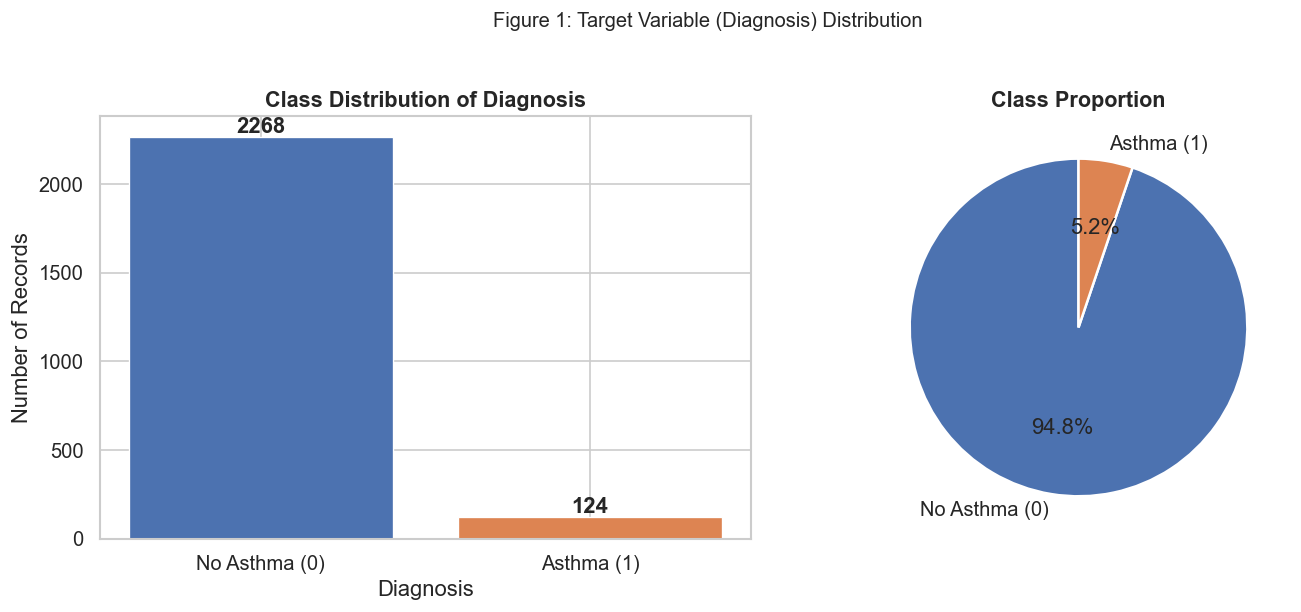

Figure 1 saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4C72B0', '#DD8452']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution of Diagnosis', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Number of Records')
for i, (label, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Target Variable (Diagnosis) Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

### Visualization 2 — Age Distribution by Diagnosis

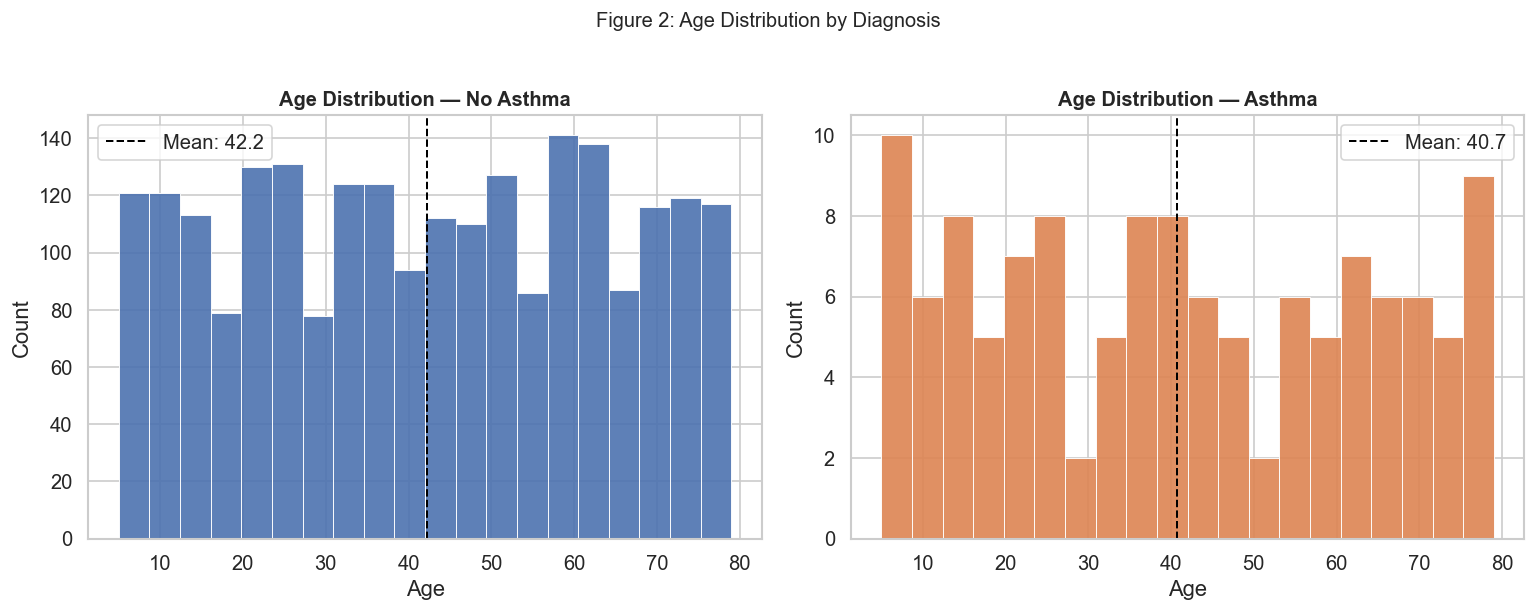

Figure 2 saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (diag, grp) in zip(axes, df_clean.groupby('Diagnosis')):
    label = 'Asthma' if diag == 1 else 'No Asthma'
    color = '#DD8452' if diag == 1 else '#4C72B0'
    ax.hist(grp['Age'], bins=20, color=color, edgecolor='white', linewidth=0.6, alpha=0.9)
    ax.set_title(f'Age Distribution — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
    ax.axvline(grp['Age'].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {grp["Age"].mean():.1f}')
    ax.legend()

plt.suptitle('Figure 2: Age Distribution by Diagnosis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig2_age_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

### Visualization 3 — BMI Distribution by Diagnosis

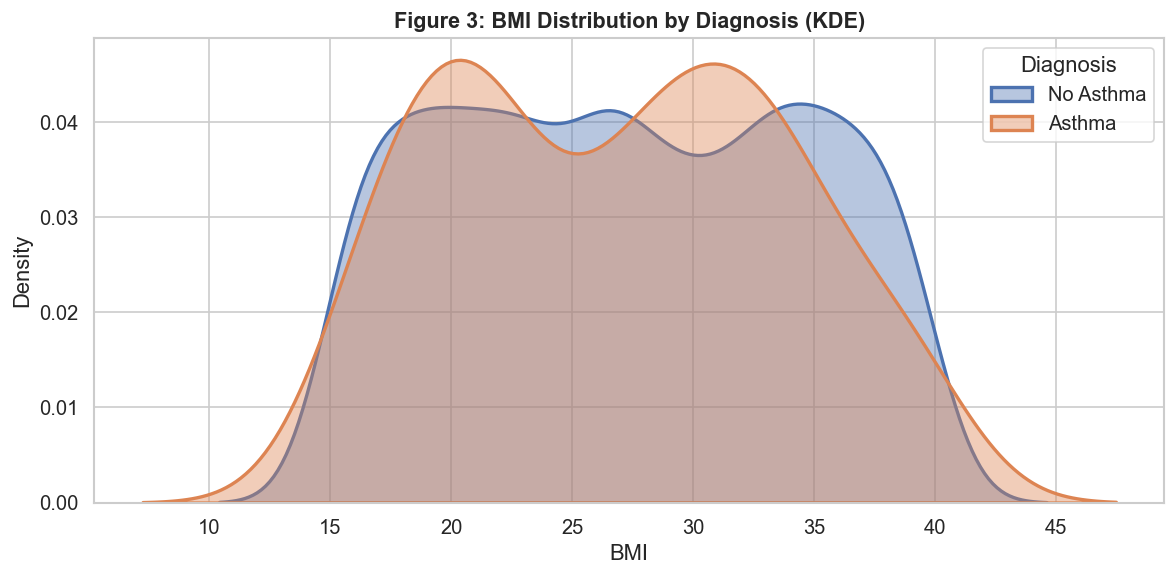

Figure 3 saved.


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for diag, grp in df_clean.groupby('Diagnosis'):
    label = 'Asthma' if diag == 1 else 'No Asthma'
    color = '#DD8452' if diag == 1 else '#4C72B0'
    sns.kdeplot(grp['BMI'], ax=ax, label=label, color=color, fill=True, alpha=0.4, linewidth=2)

ax.set_title('Figure 3: BMI Distribution by Diagnosis (KDE)', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Density')
ax.legend(title='Diagnosis')

plt.tight_layout()
plt.savefig('fig3_bmi_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

### Visualization 4 — Lung Function (FEV1 vs FVC) by Diagnosis

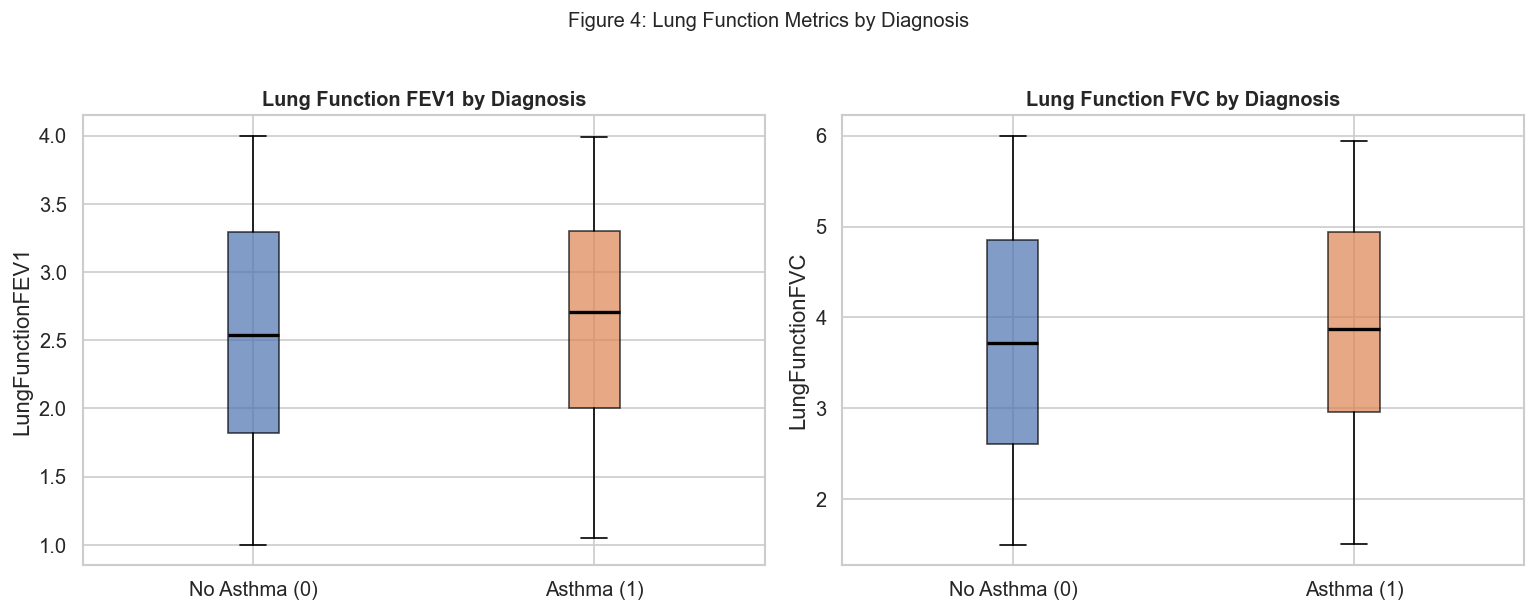

Figure 4 saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lung_cols = ['LungFunctionFEV1', 'LungFunctionFVC']
titles = ['Lung Function FEV1 by Diagnosis', 'Lung Function FVC by Diagnosis']
colors_box = ['#4C72B0', '#DD8452']

for ax, col, title in zip(axes, lung_cols, titles):
    groups = [df_clean.loc[df_clean['Diagnosis'] == 0, col].values,
              df_clean.loc[df_clean['Diagnosis'] == 1, col].values]
    bp = ax.boxplot(groups, labels=['No Asthma (0)', 'Asthma (1)'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Figure 4: Lung Function Metrics by Diagnosis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig4_lung_function.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

### Visualization 5 — Symptom Prevalence by Diagnosis (Grouped Bar)

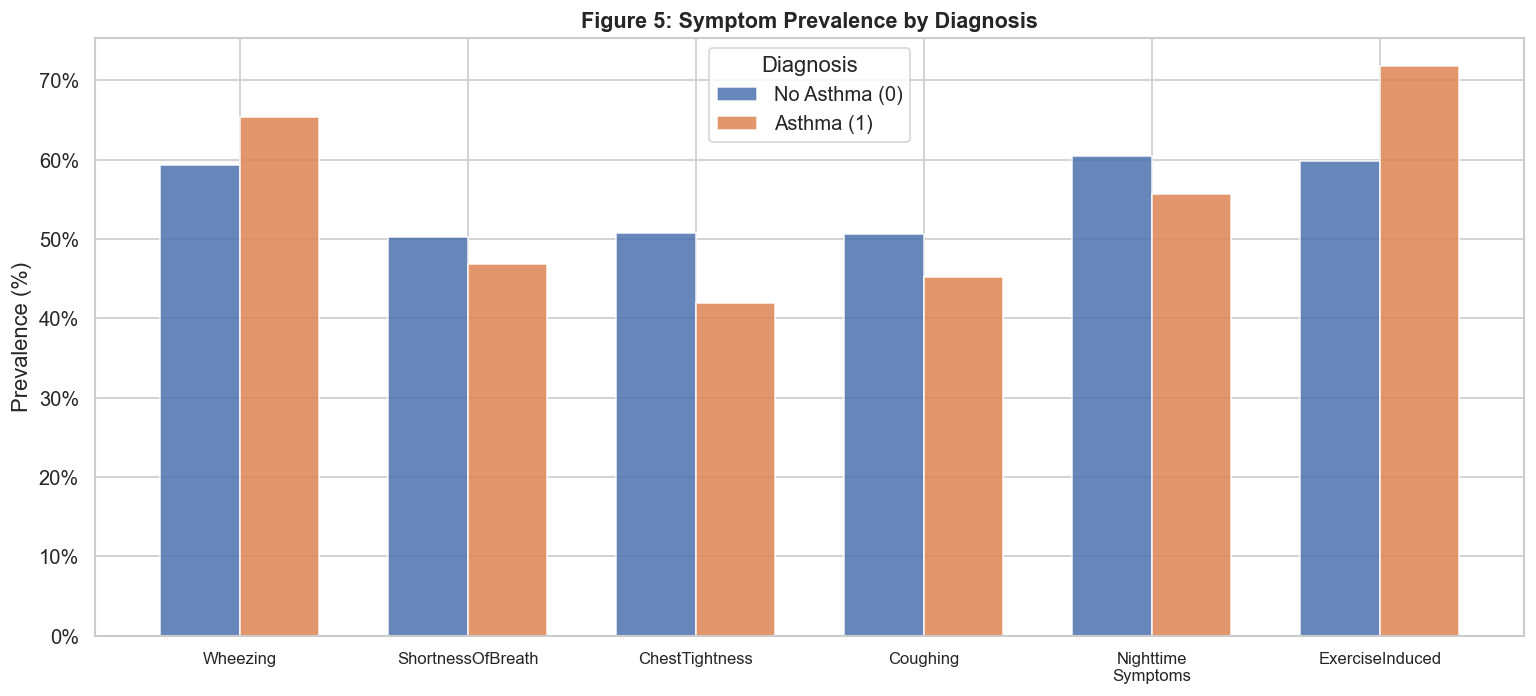

Figure 5 saved.


In [13]:
symptom_cols = ['Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']

symptom_rates = df_clean.groupby('Diagnosis')[symptom_cols].mean() * 100

x = np.arange(len(symptom_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, symptom_rates.loc[0], width, label='No Asthma (0)', color='#4C72B0', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, symptom_rates.loc[1], width, label='Asthma (1)', color='#DD8452', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('Symptom', '\nSymptom') for c in symptom_cols], fontsize=10)
ax.set_ylabel('Prevalence (%)')
ax.set_title('Figure 5: Symptom Prevalence by Diagnosis', fontsize=13, fontweight='bold')
ax.legend(title='Diagnosis')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('fig5_symptom_prevalence.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

### Visualization 6 — Correlation Heatmap of Continuous Features

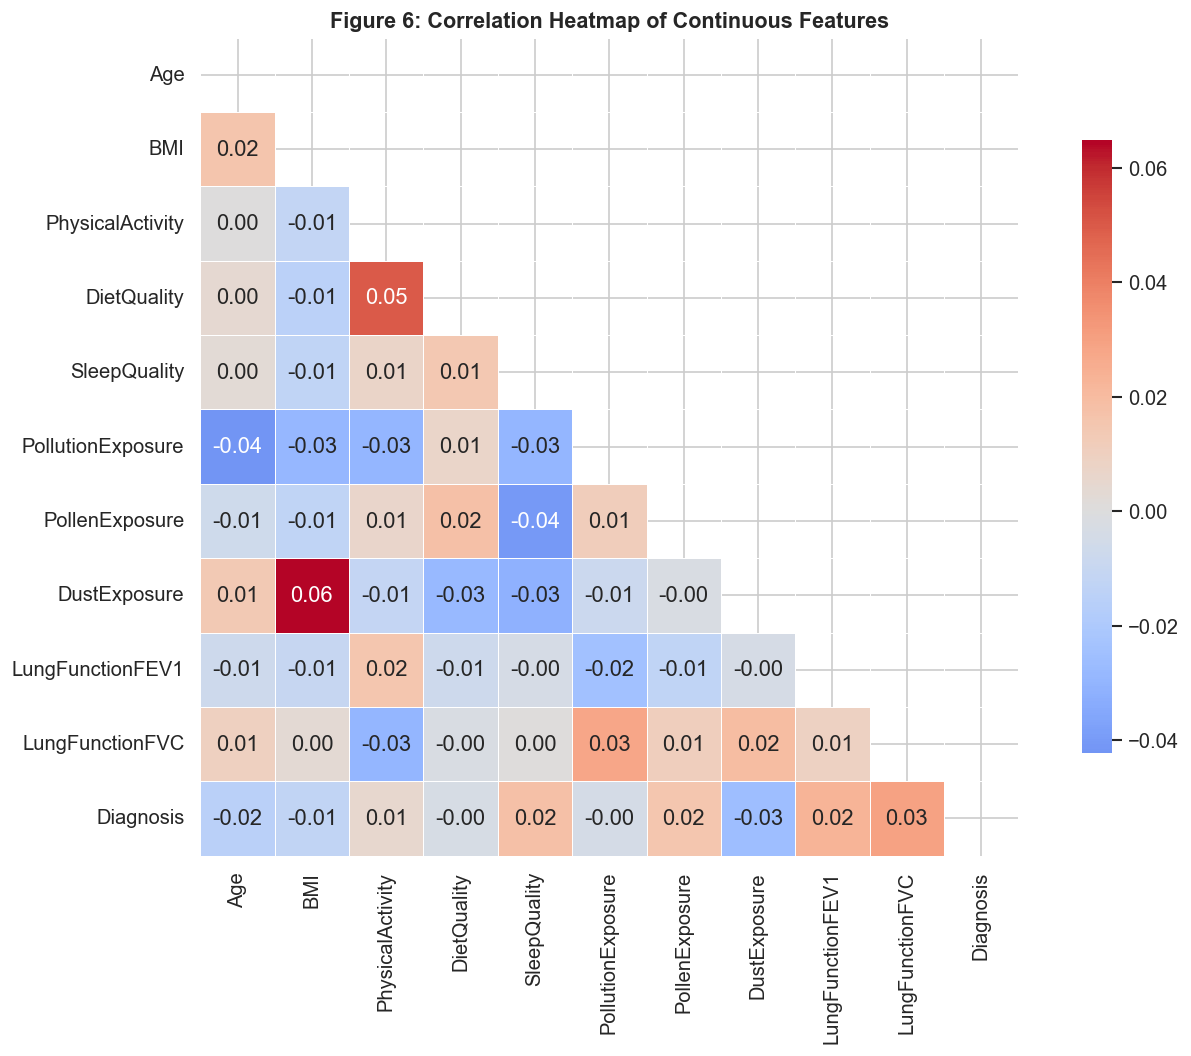

Figure 6 saved.


In [14]:
continuous_cols = ['Age', 'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
                   'PollutionExposure', 'PollenExposure', 'DustExposure',
                   'LungFunctionFEV1', 'LungFunctionFVC', 'Diagnosis']

corr_matrix = df_clean[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.75}
)

ax.set_title('Figure 6: Correlation Heatmap of Continuous Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

### Visualization 7 — Risk Factor Prevalence (Binary Features)

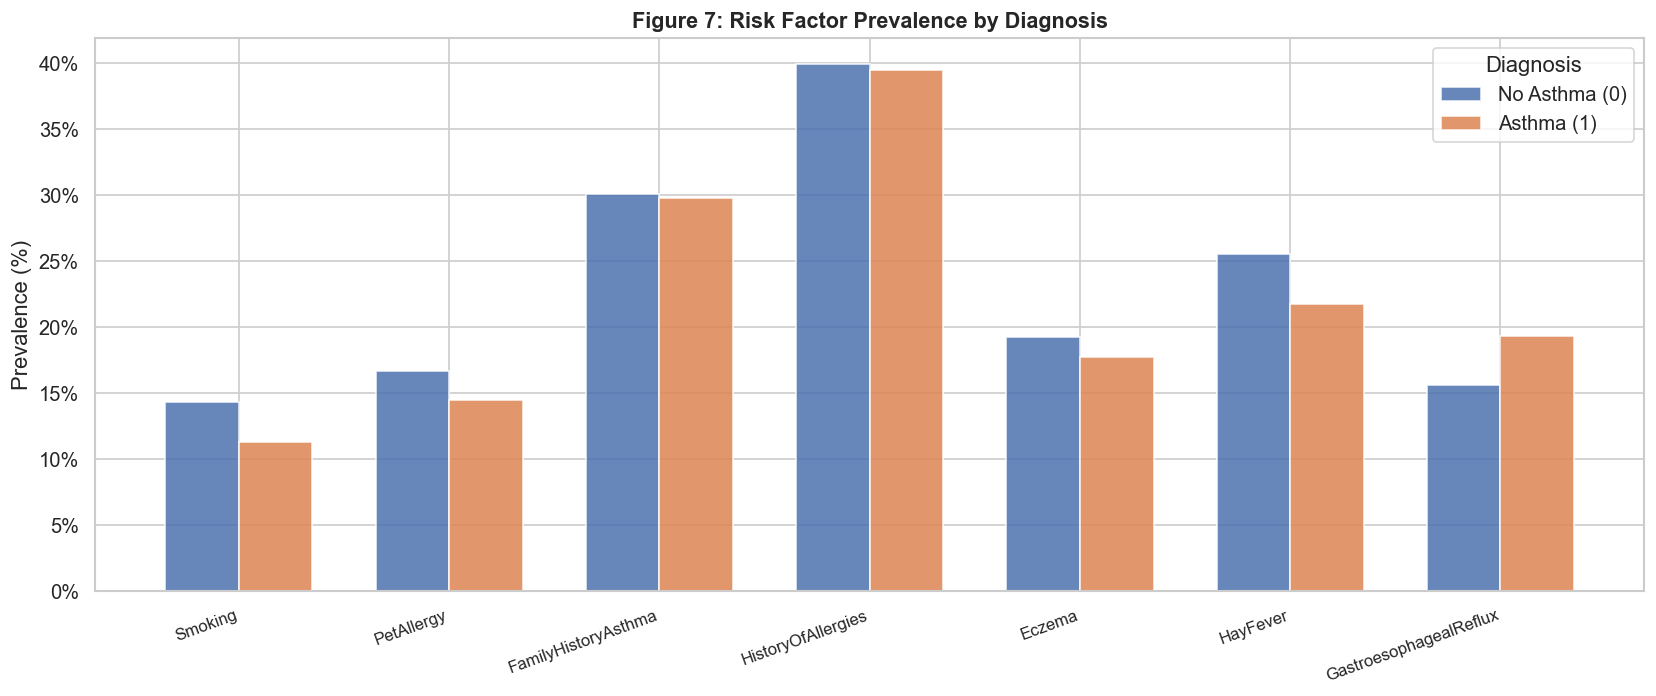

Figure 7 saved.


In [15]:
risk_cols = ['Smoking', 'PetAllergy', 'FamilyHistoryAsthma',
             'HistoryOfAllergies', 'Eczema', 'HayFever', 'GastroesophagealReflux']

risk_rates = df_clean.groupby('Diagnosis')[risk_cols].mean() * 100

x = np.arange(len(risk_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, risk_rates.loc[0], width, label='No Asthma (0)', color='#4C72B0', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, risk_rates.loc[1], width, label='Asthma (1)', color='#DD8452', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(risk_cols, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Prevalence (%)')
ax.set_title('Figure 7: Risk Factor Prevalence by Diagnosis', fontsize=13, fontweight='bold')
ax.legend(title='Diagnosis')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('fig7_risk_factors.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

---
## 6. Summary Statistics Table

In [16]:
key_cols = ['Age', 'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'LungFunctionFEV1', 'LungFunctionFVC']

summary = df_clean.groupby('Diagnosis')[key_cols].agg(['mean', 'std']).round(2)
summary.index = ['No Asthma (0)', 'Asthma (1)']

print('Summary Statistics — Key Features by Diagnosis:')
summary

Summary Statistics — Key Features by Diagnosis:


Age           BMI       PhysicalActivity       DietQuality  \
                mean    std   mean   std             mean   std        mean   
No Asthma (0)  42.21  21.55  27.27  7.22             5.05  2.91        5.03   
Asthma (1)     40.74  22.75  26.86  6.93             5.11  2.88        4.98   

                    SleepQuality       LungFunctionFEV1       LungFunctionFVC  \
                std         mean   std             mean   std            mean   
No Asthma (0)  2.91         7.01  1.73             2.54  0.86            3.73   
Asthma (1)     2.92         7.15  1.70             2.63  0.81            3.91   

                     
                std  
No Asthma (0)  1.30  
Asthma (1)     1.31

---
## 7. Observations and Interpretation

Based on the exploratory data analysis conducted on the Asthma Disease Dataset (2,392 records, 27 usable features), the following observations were identified:

**1. Severe Class Imbalance.** The target variable `Diagnosis` is heavily skewed: approximately **94.8% of records are classified as No Asthma (0)**, while only **5.2% are classified as Asthma (1)**. This pronounced imbalance indicates that any machine learning model trained on this dataset will be strongly biased toward predicting the majority class. Resampling techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or class-weight adjustments will be necessary during model training to prevent misleading accuracy scores.

**2. Lung Function as a Discriminating Feature.** The boxplot analysis (Figure 4) reveals that patients diagnosed with asthma tend to have noticeably lower **LungFunctionFEV1** and **LungFunctionFVC** values compared to non-asthmatic patients. This difference in distribution suggests that lung function measurements are strong candidate features for classification and are likely to carry high feature importance in tree-based and linear models.

**3. Higher Symptom Burden in Asthma Cases.** Asthma-positive patients exhibit a markedly higher prevalence across all recorded respiratory symptoms — including **wheezing, shortness of breath, chest tightness, coughing, nighttime symptoms, and exercise-induced symptoms** (Figure 5). These symptom features collectively form a reliable clinical signal and are expected to contribute significantly to model performance.

**4. Risk Factors Show Moderate Differentiation.** Environmental and medical history factors such as **FamilyHistoryAsthma**, **HistoryOfAllergies**, and **HayFever** show higher prevalence in the asthma group (Figure 7). However, lifestyle factors such as **BMI** and **PhysicalActivity** show overlapping distributions between the two classes (Figures 2 and 3), suggesting they are weak standalone predictors but may contribute when combined with other features.

**5. Low Multicollinearity Among Features.** The correlation heatmap (Figure 6) indicates that most features are weakly correlated with each other. The strongest correlation observed is between **LungFunctionFEV1 and LungFunctionFVC** (expected physiologically). The low inter-feature correlation suggests that most features contribute independent information, which is favorable for model training and reduces the risk of redundant predictors inflating model complexity.

---
*End of Lab Activity 2 — EDA Implementation*  
*IT325 Machine Learning | John Michael Angelo Binonggo*